### Logistic Regression Model
This notebook focuses on predictions using the Logistic Regression model. The model is trained and evaluated on preprocessed data, with metrics such as accuracy, precision, recall, and F1 score. A confusion matrix is included to visualize performance, and the model is trained on scaled features to ensure better convergence.

In [18]:
%run data_prep.ipynb

Accuracy: 0.8309785996260128
Precision: 0.8665212217374058
Recall: 0.8207777569040015
F1 Score: 0.8430294259527256
ROC AUC: 0.9110389585725203

Confusion Matrix:
[[3630  673]
 [ 954 4369]]


/Users/graciousasare/Documents/Fall 2025/BTT/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


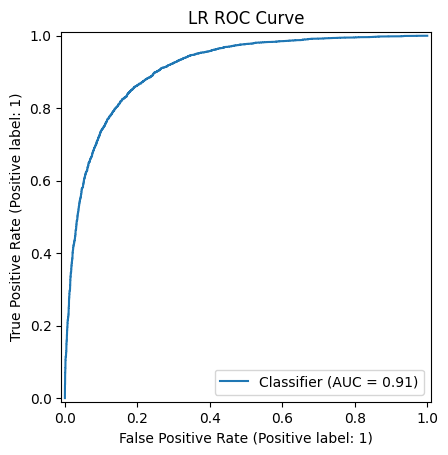

In [19]:
# Simple Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelEncoder


# Convert y_train and y_test to numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


# Train
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train_enc)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate
acc = accuracy_score(y_test_enc, y_pred)
prec = precision_score(y_test_enc, y_pred)
rec = recall_score(y_test_enc, y_pred)
f1 = f1_score(y_test_enc, y_pred)
roc = roc_auc_score(y_test_enc, y_prob)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("ROC AUC:", roc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))

# ROC curve
RocCurveDisplay.from_predictions(y_test_enc, y_prob)
plt.title("LR ROC Curve")
plt.show()


In [20]:
# Save the best model- file created and moved to saved_models folder
# import pickle
# with open('logistic_regression_model.pkl', 'wb') as f:
#     pickle.dump(model, f)